In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/online exam.csv")
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54833 entries, 0 to 54832
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ride_id             54833 non-null  object        
 1   rideable_type       54833 non-null  object        
 2   started_at          54833 non-null  datetime64[ns]
 3   ended_at            54833 non-null  datetime64[ns]
 4   start_station_name  54833 non-null  object        
 5   start_station_id    54833 non-null  object        
 6   end_station_name    54709 non-null  object        
 7   end_station_id      54667 non-null  object        
 8   start_lat           54833 non-null  float64       
 9   start_lng           54833 non-null  float64       
 10  end_lat             54817 non-null  float64       
 11  end_lng             54817 non-null  float64       
 12  member_casual       54833 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(7)
me

In [5]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,28A17ACD224CD80B,electric_bike,2024-12-06 17:50:49.428,2024-12-06 17:54:20.070,Oakland Ave,JC022,Hilltop,JC019,40.737604,-74.052478,40.731169,-74.057574,member
1,3508393A86FBD357,classic_bike,2024-12-14 11:01:00.309,2024-12-14 11:12:01.382,Oakland Ave,JC022,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.737604,-74.052478,40.735938,-74.030305,member
2,75FA4C03A1447401,electric_bike,2024-12-24 08:07:17.475,2024-12-24 08:14:14.612,Oakland Ave,JC022,Leonard Gordon Park,JC080,40.737604,-74.052478,40.745910,-74.057271,member
3,C7741EF495C597DD,classic_bike,2024-12-19 12:48:05.452,2024-12-19 12:54:15.253,Oakland Ave,JC022,Leonard Gordon Park,JC080,40.737604,-74.052478,40.745910,-74.057271,member
4,07952BB20B46C5B1,electric_bike,2024-12-17 11:19:37.631,2024-12-17 11:28:25.150,Oakland Ave,JC022,Grove St PATH,JC115,40.737604,-74.052478,40.719410,-74.043090,casual


In [6]:
df.isnull().sum()


,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,124
end_station_id,166
start_lat,0
start_lng,0


In [3]:
df.dropna(inplace=True)
df.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,0
end_station_id,0
start_lat,0
start_lng,0


<Axes: xlabel='start_station_name'>

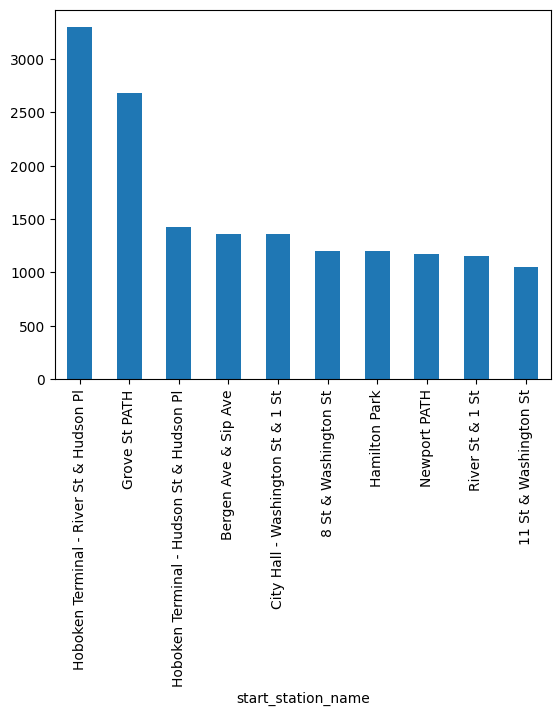

In [7]:
start_counts = df['start_station_name'].value_counts()
start_counts.head(10).plot(kind='bar')


<ipython-input-4-e18c9c1318f9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='coolwarm')


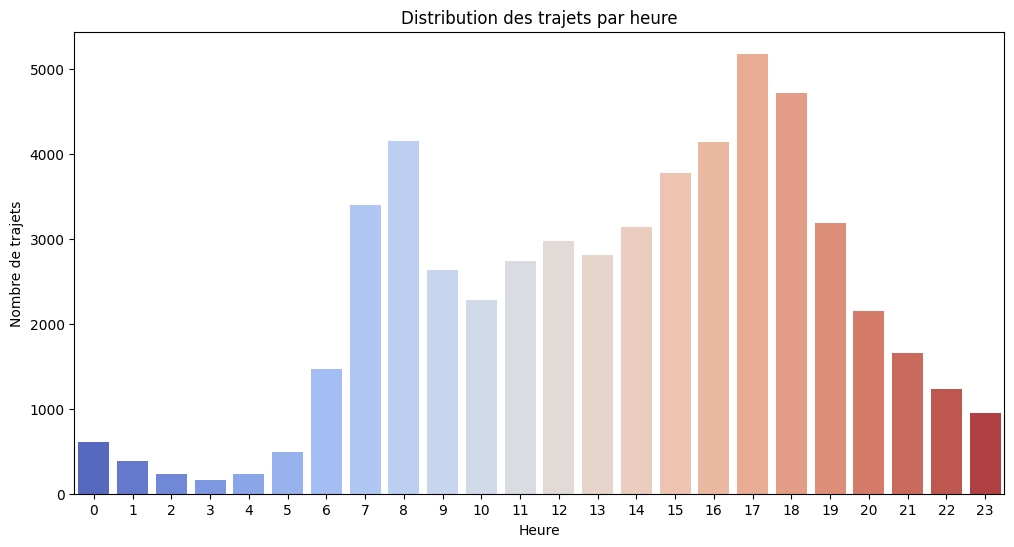

<ipython-input-4-e18c9c1318f9>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week', data=df, palette='viridis')


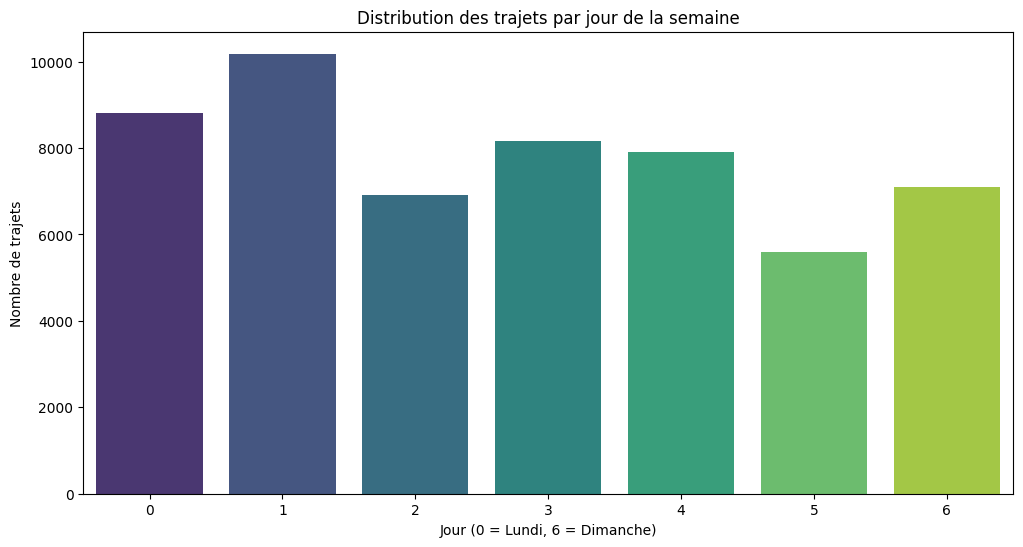

<ipython-input-4-e18c9c1318f9>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month', data=df, palette='cool')


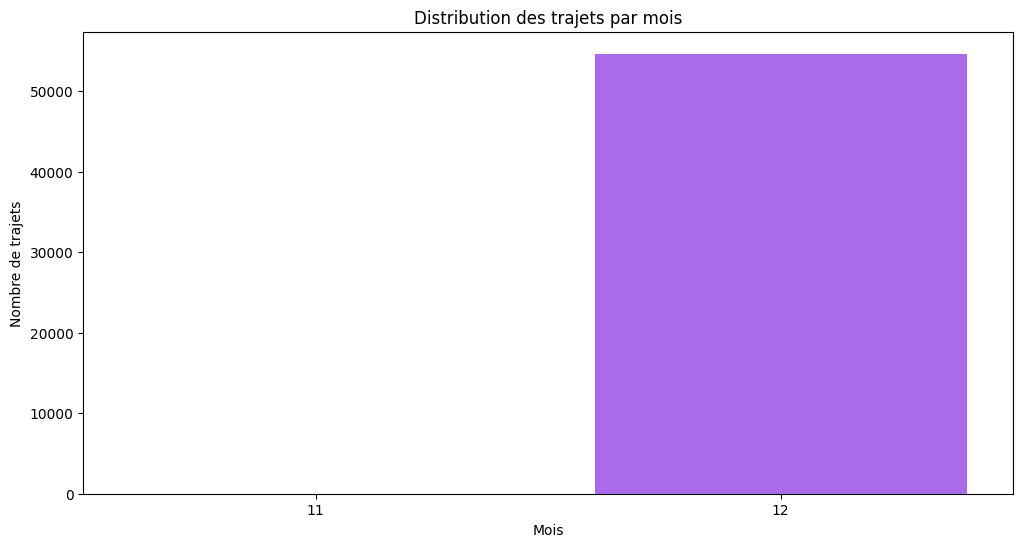

In [4]:

df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.dayofweek
df['month'] = df['started_at'].dt.month


plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=df, palette='coolwarm')
plt.title("Distribution des trajets par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre de trajets")
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(x='day_of_week', data=df, palette='viridis')
plt.title("Distribution des trajets par jour de la semaine")
plt.xlabel("Jour (0 = Lundi, 6 = Dimanche)")
plt.ylabel("Nombre de trajets")
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(x='month', data=df, palette='cool')
plt.title("Distribution des trajets par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de trajets")
plt.show()


<ipython-input-5-c0a4403888b8>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_end_stations.values, y=top_end_stations.index, palette='Greens_r')


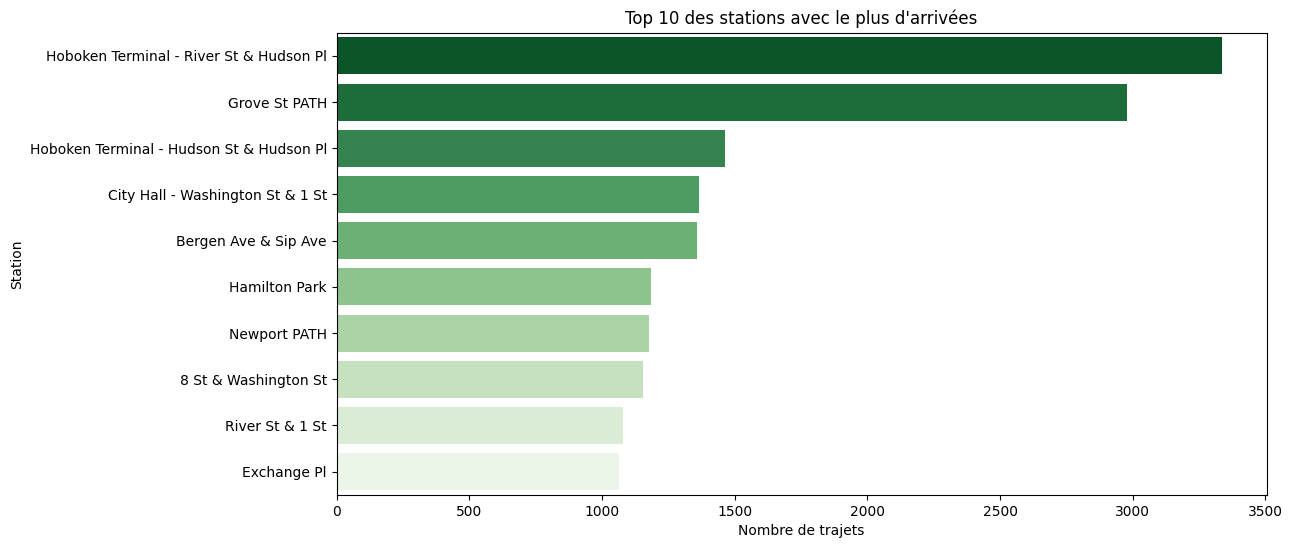

In [5]:
top_end_stations = df['end_station_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_end_stations.values, y=top_end_stations.index, palette='Greens_r')
plt.title("Top 10 des stations avec le plus d'arrivées")
plt.xlabel("Nombre de trajets")
plt.ylabel("Station")
plt.show()

<ipython-input-6-25c914b6579b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rideable_type', data=df, palette='pastel')


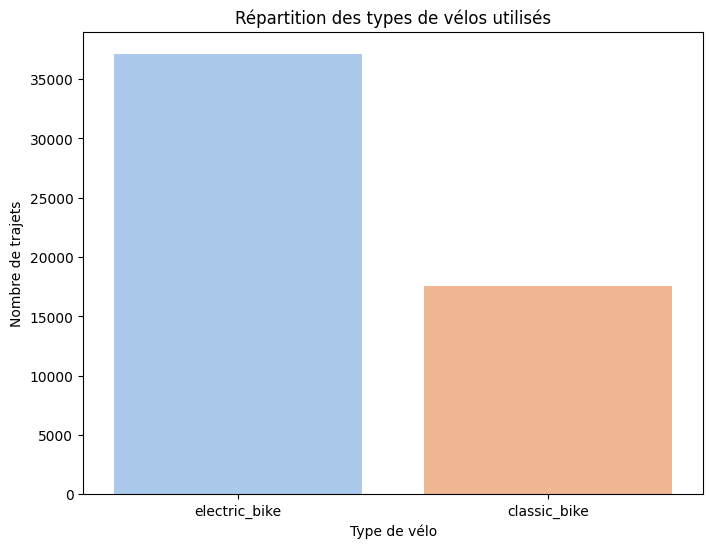

In [6]:

plt.figure(figsize=(8, 6))
sns.countplot(x='rideable_type', data=df, palette='pastel')
plt.title("Répartition des types de vélos utilisés")
plt.xlabel("Type de vélo")
plt.ylabel("Nombre de trajets")
plt.show()


In [7]:
import plotly.express as px


fig = px.scatter_mapbox(
    df,
    lat="start_lat",
    lon="start_lng",
    color="member_casual",
    zoom=10,
    title="Localisation des stations de départ",
    mapbox_style="carto-positron"
)
fig.show()


In [8]:

df['time_interval'] = df['started_at'].dt.floor('60T')

# Aggregate by start_station_id and time interval
station_demand = df.groupby(['start_station_id', 'time_interval']).size().reset_index(name='demand')

# Step 2: Add time-based features
station_demand['hour'] = station_demand['time_interval'].dt.hour
station_demand['day_of_week'] = station_demand['time_interval'].dt.dayofweek
station_demand['month'] = station_demand['time_interval'].dt.month

# Step 3: Create the target variable (next 60 minutes demand)
station_demand['next_hour_demand'] = station_demand.groupby('start_station_id')['demand'].shift(-1)

# Step 4: Handle missing values
# Fill missing 'demand' with 0 for time intervals where there was no data
station_demand['demand'] = station_demand['demand'].fillna(0)

<ipython-input-8-0a199ab58c44>:1: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



In [5]:
station_demand.head()

,start_station_id,time_interval,demand,hour,day_of_week,month,next_hour_demand
0,HB101,2024-12-01 00:00:00,3,0,6,12,3.0
1,HB101,2024-12-01 01:00:00,3,1,6,12,1.0
2,HB101,2024-12-01 02:00:00,1,2,6,12,1.0
3,HB101,2024-12-01 03:00:00,1,3,6,12,3.0
4,HB101,2024-12-01 10:00:00,3,10,6,12,1.0


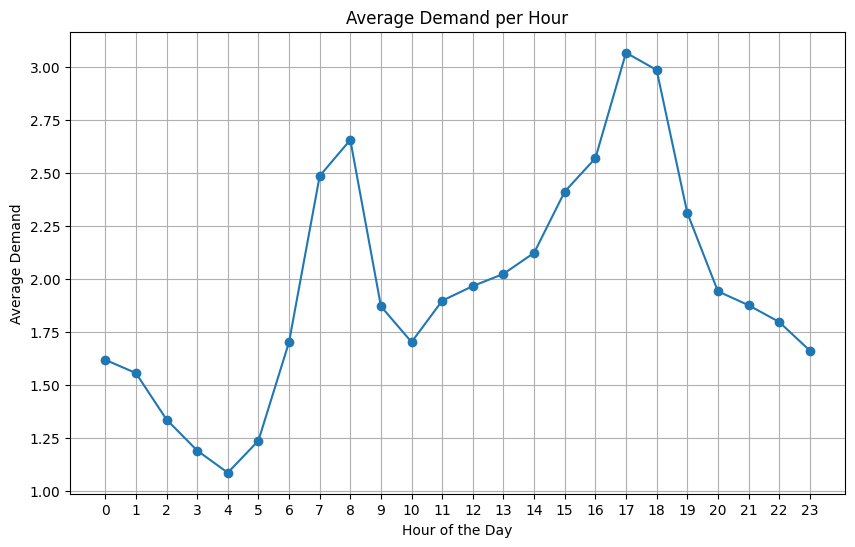

In [11]:


import matplotlib.pyplot as plt


hourly_demand = station_demand.groupby('hour')['demand'].mean()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(hourly_demand.index, hourly_demand.values, marker='o')
plt.title('Average Demand per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Demand')
plt.xticks(range(24))  # Ensure all hours are shown on the x-axis
plt.grid(True)
plt.show()

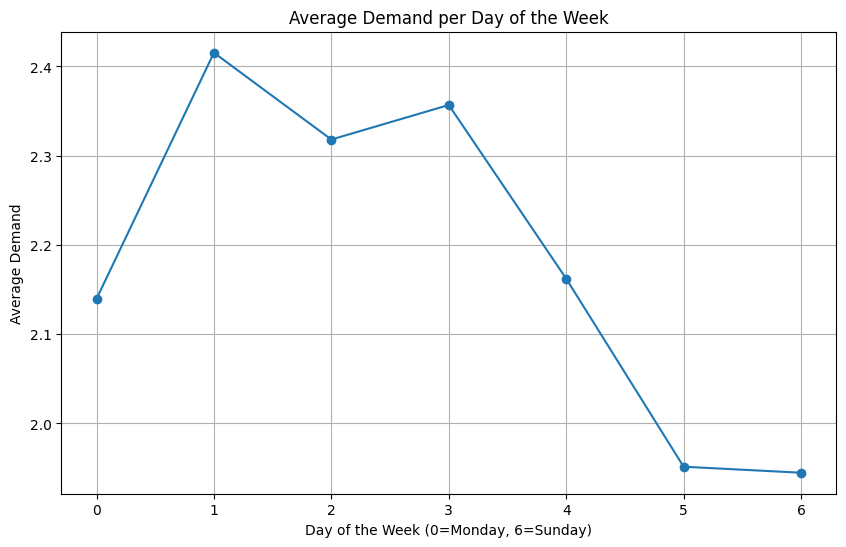

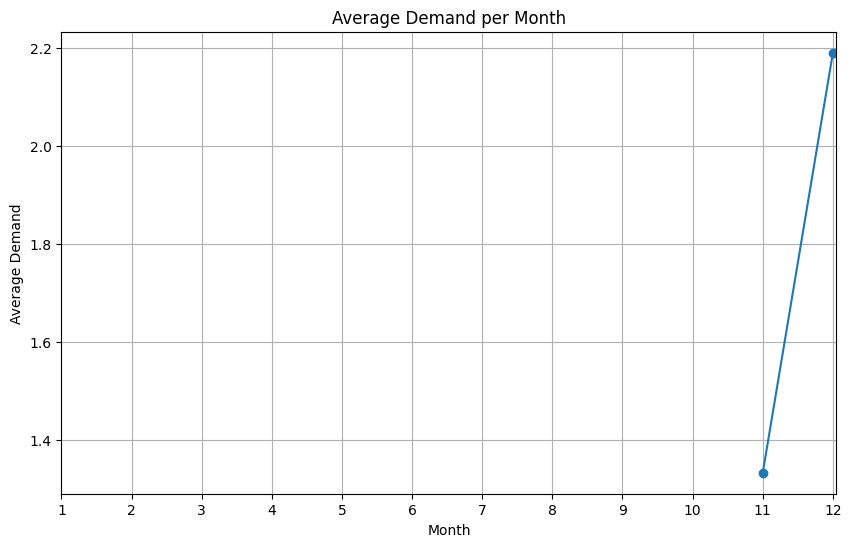

In [12]:


# Group by day of the week and calculate the average demand
daily_demand = station_demand.groupby('day_of_week')['demand'].mean()

# Create the plot for daily demand
plt.figure(figsize=(10, 6))
plt.plot(daily_demand.index, daily_demand.values, marker='o')
plt.title('Average Demand per Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Demand')
plt.xticks(range(7))  # Ensure all days are shown on the x-axis
plt.grid(True)
plt.show()


# Group by month and calculate the average demand
monthly_demand = station_demand.groupby('month')['demand'].mean()

# Create the plot for monthly demand
plt.figure(figsize=(10, 6))
plt.plot(monthly_demand.index, monthly_demand.values, marker='o')
plt.title('Average Demand per Month')
plt.xlabel('Month')
plt.ylabel('Average Demand')
plt.xticks(range(1, 13))  # Ensure all months are shown on the x-axis
plt.grid(True)
plt.show()

In [6]:
station_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24953 entries, 0 to 24952
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   start_station_id  24953 non-null  object        
 1   time_interval     24953 non-null  datetime64[ns]
 2   demand            24953 non-null  int64         
 3   hour              24953 non-null  int32         
 4   day_of_week       24953 non-null  int32         
 5   month             24953 non-null  int32         
 6   next_hour_demand  24870 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(1)
memory usage: 1.0+ MB


In [7]:
# Sort data by time_interval to ensure chronological order
station_demand = station_demand.sort_values(by=['time_interval'])

# Define the split ratio
train_ratio = 0.8
split_index = int(len(station_demand) * train_ratio)

# Split the dataset
train_data = station_demand.iloc[:split_index]
test_data = station_demand.iloc[split_index:]

# Reset indices for cleaner output
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Print the sizes of the splits
print(f"Training set size: {len(train_data)} rows")
print(f"Testing set size: {len(test_data)} rows")


Training set size: 19962 rows
Testing set size: 4991 rows


In [9]:

from sklearn.preprocessing import MinMaxScaler

# Select relevant features for LSTM
features = ['start_station_id', 'hour', 'day_of_week', 'month', 'demand']
train_data_lstm = train_data[features]
test_data_lstm = test_data[features]

# Convert 'start_station_id' to numerical representation
station_id_mapping = {id: i for i, id in enumerate(train_data_lstm['start_station_id'].unique())}
train_data_lstm['start_station_id'] = train_data_lstm['start_station_id'].map(station_id_mapping)
test_data_lstm['start_station_id'] = test_data_lstm['start_station_id'].map(station_id_mapping)

# Fill NaN values in test data (if any)
test_data_lstm['start_station_id'] = test_data_lstm['start_station_id'].fillna(0)


# Scale features using MinMaxScaler
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data_lstm)
test_data_scaled = scaler.transform(test_data_lstm)

# Reshape the data for LSTM input
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length, -1]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 24
X_train, y_train = create_sequences(train_data_scaled, seq_length)
X_test, y_test = create_sequences(test_data_scaled, seq_length)



<ipython-input-9-f26a5ec5e0b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_lstm['start_station_id'] = train_data_lstm['start_station_id'].map(station_id_mapping)
<ipython-input-9-f26a5ec5e0b0>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data_lstm['start_station_id'] = test_data_lstm['start_station_id'].map(station_id_mapping)
<ipython-input-9-f26a5ec5e0b0>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the LSTM model
def create_lstm_model(input_shape):
    model = Sequential()

    # LSTM layer with 50 units
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))  # Dropout to prevent overfitting

    # Second LSTM layer
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.2))

    # Fully connected Dense layer
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(1))  # Predict next-hour demand

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    return model

# Define input shape (number of timesteps, number of features)
input_shape = X_train.shape[1:]  # e.g., 10 timesteps, features include demand, hour, etc.

# Create the model
lstm_model = create_lstm_model(input_shape)

# Display the model summary
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 24, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Configure early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
loss, mae = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.0028 - mae: 0.0313 - val_loss: 0.0011 - val_mae: 0.0263
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - loss: 0.0024 - mae: 0.0298 - val_loss: 9.0039e-04 - val_mae: 0.0215
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.0023 - mae: 0.0291 - val_loss: 8.6291e-04 - val_mae: 0.0207
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - loss: 0.0024 - mae: 0.0288 - val_loss: 9.0271e-04 - val_mae: 0.0182
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - loss: 0.0024 - mae: 0.0290 - val_loss: 9.8309e-04 - val_mae: 0.0247
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0027 - mae: 0.0296 - val_loss: 9.6853e-04 - val_mae: 0.0243
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - loss: 0.0023 - mae: 0.0286 - val_loss: 9.2735e-04 - val_mae: 0.0231
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - loss: 0.0024 - mae: 0.0282 - val_loss: 8.7754e-04 - val_mae: 0.0216
Epoch 9/10
6